<a href="https://colab.research.google.com/github/mysticgrud/magshimim/blob/class-21/%D7%A2%D7%95%D7%AA%D7%A7_%D7%A9%D7%9C_%D7%9E%D7%97%D7%91%D7%A8%D7%AA_%D7%9C%D7%99%D7%91%D7%99_%D7%91%D7%9F_%D7%90%D7%9C%D7%99%D7%94%D7%95_%D7%A9%D7%99%D7%9E%D7%95%D7%A9_%D7%91SKLEARN_%D7%A2%D7%9D_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center>

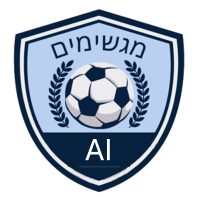

<div dir="rtl">
<font color="Grey">
זכרו ליצור עותק של מחברת זו, לשנות את שמו ולעבוד על העותק האישי שלכם.
<br>
בהצלחה!
</font>
</div>

<div dir="rtl" align="center">
<b><font color="Grey">
שיעור 21</font></b>
<H1>
<font color='#141C3A'>
<b>לימוד עצמי של שימוש בספריה sklearn ומודל KNN</b>
</font>
</H1>
</div>


<div dir="rtl">

# שלב 1: ייבא את הספריות הדרושות
ראשית, עלינו לייבא את הספריות הדרושו pandas ו-sklearn.

**Scikit-learn:** היא ספרייה ללמידת מכונה בפייתון. היא מספקת כלים לעיבוד של נתונים, בחירת פיצ'רים, בחירת מודלים והערכתם.

נשתמש במודולים שראינו בשיעור:

**sklearn.model_selection:** מודול זה מספק פונקציות שונות לפיצול מערך נתונים לקבוצות של נתונים לאימון ולבדיקה של המודל שלנו. הפונקציה train_test_split משמשת בדרך כלל לפיצול אקראי של הנתונים לקבוצות אימון ובדיקות.

**sklearn.neighbors:** מודול זה מכיל אלגוריתמים שונים לביצוע סיווג ורגרסיה של השכנים הקרובים ביותר. המסווג KNeighborsClassifier היא בחירה פופולרית לבעיות סיווג ומשמשת ליישום אלגוריתם ה-KNN.

לאחר שהבנו קצת אילו ספריות אנו צריכים וקיבלנו תמונה כללית , בואות נריץ את הייבוא של הספריות האלה בפייתון:

In [ ]:
# Import necessary libraries
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

<div dir="rtl">

# שלב 2: נטען את הנתונים
אנחנו נטען את הנתונים שלנו דרך הלינק הנתון לקובץ בגוגל דרייב באמצעות ספריית Pandas. אך אם נדביק ישירות את הלינק ב read_csv היא לא תצליח לטעון אותו כי הלינק לא יהיה בפורמט הדרוש . על מנת להפוך את הלינק לפורמט הCSV המקובל ניעזר בפונקציה שיצרנו במיוחד ששמה:
**read_csv_from_googledrive**
שראיתם בעבר.

ממליצים לשמור אותה לעצמכם ולהישמש בה שוב בעצמכם בפעמים הבאות. הפונקציה תהפוך את פורמט הURL לנדרש. לאחר מכן נטען את הCSV ונחזיר DF של הנתונים.

[קובץ הנתונים נתון לכם כאן](https://drive.google.com/file/d/1iynP8bKmw7Gy7SVazG3K3K15syOM8SG1/view?usp=sharing)

הוסיפו וחקרו קצת את הקובץ.
נעסוק בכדורים השונים שמשמשים לסוגי הספורט השונים ולאחר מכן נסווג אותם.

אנו נשתמש במערך נתונים המכיל מידע על סוגי הכדורים. מערך הנתונים מכיל את המשתנים
 הבאים:

**סוג**: מתייחס לסוג הכדור, כגון כדורגל, כדורסל, כדורגל אמריקאי(פוטבול) וכו'.

**משקל**: מתייחס למשקל הכדור בגרמים.

**קוטר**: מתייחס לקוטר הכדור

**היקף**: מתייחס להיקף הכדור

**הקפצה**: מתייחס לגובה הקפצת הכדור, כאשר הוא נפל מגובה ומשטח מוגדרים.

**צורה**: מתייחס לצורת הכדור, בין אם הוא מעגלי או אליפטי .

<BR>



In [ ]:
#@title טעינת נתונים

#LINK TO DATA:
#https://drive.google.com/file/d/1iynP8bKmw7Gy7SVazG3K3K15syOM8SG1/view?usp=sharing


import pandas as pd
def read_csv_from_googledrive(url):
  #Split the url to be something like https://drive.google.com/uc?id=1iynP8bKmw7Gy7SVazG3K3K15syOM8SG1
  url='https://drive.google.com/uc?id=' + url.split('/')[-2]
  df=pd.read_csv(url)
  return df

df=read_csv_from_googledrive("https://drive.google.com/file/d/1iynP8bKmw7Gy7SVazG3K3K15syOM8SG1/view")
df

,Type,Weight,Diameter,Circumference,Bounce,Shape
0,Rugby ball,415.85,19.65,67.85,149.21,Ellipse
1,Tennis ball,67.31,5.92,20.85,117.93,Circle
2,Soccer ball,458.76,26.64,65.38,139.02,Circle
3,Basketball,495.96,26.28,76.30,152.48,Circle
4,Soccer ball,483.91,26.99,74.29,138.68,Circle
...,...,...,...,...,...,...
2995,Rugby ball,442.83,20.10,69.53,145.79,Ellipse
2996,Rugby ball,445.10,21.72,69.82,149.67,Ellipse
2997,Basketball,482.11,25.59,75.84,157.67,Circle
2998,Basketball,484.72,24.29,76.08,158.54,Circle


<div dir="rtl">

**משימה**

אילו מאפיינים לדעתכם ניתן להוסיף כאן שיכלו לעזור לסיווג סוג הכדור?




--------------------------------------------------------------------------------
<div dir="rtl">
<font color='Green' size="5">
<b>
ענו כאן אווירודינמיות, חברת ייצור</font>

--------------------------------------------------------------------------------

<div dir="rtl">


# שלב 3: הכן את הנתונים
נניח כי הנתונים שלנו תקינים ואין ערכים חסרים או חריגים.
בשלב זה נעבוד רק עם משתנים כמותיים.
**ננסה לסווג את צבע הכדור החדש שיקבל**.
חקרו אודות המשתנים מה ניתן ללמוד עליהם?
השתמשו באחת מהפעולות שלמדנו ובדקנו שאכן הנתונים תקינים.

In [ ]:
#השלימו כאן קטע קוד
df.describe()

,Weight,Diameter,Circumference,Bounce
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,338.152697,17.441637,57.125713,122.892790
std,172.001150,8.033582,24.330374,31.452877
min,50.010000,5.900000,20.000000,48.020000
25%,125.645000,6.810000,22.937500,112.820000
50%,430.495000,19.460000,70.940000,133.060000
75%,466.055000,24.930000,75.640000,145.982500
max,519.960000,27.980000,79.990000,159.990000


<div dir="rtl">

**שלב בחירת המשתנים:**

נגדיר את מטריצת הפיצ'רים, שהיא מרכיב מרכזי במודל למידת מכונה, מכיוון שהיא
מכילה את נתוני הקלט המשמשים לאימון ובדיקת המודל. חיוני לבחור בקפידה ולעבד מראש את התכונות כדי להשיג את הסיווג הטוב ביותר מהמודל.

 לצורך הדוגמה נבחר במשקל (Weight) ובגובה הקפיצה של הכדור (Bounce) בתור הפיצ'רים שלנו כרגע.

 ונבחר את הסוג של הכדור (Type) בתור הקטגוריה שנרצה לסווג אליה.

**אנחנו מבצעים פה פירוק של הנתונים בין הפיצ'רים ללייבלים**, כלומר עמודת הלייבלים היא Type ושאר העמודות שבחרנו  הן עמודות פיצ'רים

 - נשלים את שמות העמודות שנבחר במקומות המתאימים בסוגריים המרובעים. כלומר נבחר רק את העמודות שאיתן אנחנו עובדים

- הבהרה חשובה!  מכיוון שהספריה מקבלת רק קלטים מספריים, אז נצרך לתרגם את הערכים של Type (שהם string) לערכים מספריים. נעשה זאת בהמשך התרגיל. כרגע יש להשתמש רק במאפיינים מספריים.


In [ ]:
features = df[['Weight', 'Bounce']]
labels = df['Type']

<div dir="rtl">

# שלב 4: פיצול הנתונים לסט נתונים לאימון ולסט מבחן
אנחנו צריכים לפצל את הנתונים שלנו לסט אימון ולסט מבחן כדי להעריך את הביצועים של המודל שלנו. נשתמש בפונקציה train_test_split מ-sklearn כדי לפצל את הנתונים באופן אקראי ל-70% נתוני אימון ו-30% נתוני בדיקה.

נשים לב שאנחנו שמים כפרמטרים לפונקציה את מטריצת הפיצ'רים ואת רשימת הלייבלים.

נקבל מהפונקציה את הסטים של האימון והבדיקה (train/test) מחולקים לפיצ'רים (features_train/features_test) והלייבלים המתאימים להם (labels_train/labels_test)

הריצו את השורה ההבאה:

In [ ]:
# Split the dataset into training and testing sets
features_train, features_test, labels_train, labels_test = train_test_split(features , labels , test_size=0.3, random_state=4)

<div dir="rtl">

**משימה**

הדפיסו מהו הshape  של כל אחד מהמשתנים



In [ ]:
#השלימו כאן קטע קוד
print(features_train.shape)
print(features_test.shape)
print(labels_train.shape)
print(labels_test.shape)


(2100, 2)
(900, 2)
(2100,)
(900,)


<div dir="rtl">

הסבירו מדוע זוהי כמות השורות והעמודות של אחד מהמשתנים ?




--------------------------------------------------------------------------------
<div dir="rtl">
<font color='Green' size="5">
<b>
ענו כאן
כי חילקו את הדאטאסט לשורות שונות ועושים שיש לדאטאסט שאליו מאמנים את המודל יש הכי הרבה שורות ששים אליו</font>
<br>


--------------------------------------------------------------------------------

<div dir="rtl">

# שלב 5: יצירה ואימון מודל KNN
כעת, אנו יכולים ליצור את מודל ה-KNN שלנו באמצעות מחלקת KNeighborsClassifier מ-skit-learn. נגדיר את הפרמטר n_neigbors ל-1, מה שאומר שהמודל יתחשב בשכן הקרוב ביותר בעת ביצוע תחזיות.
 לאחר מכן אנחנו גם מאמנים את המודל עם משתני האימון שהרגע קיבלנו מהפונקציה של הפיצול, הריצו את קטע הקוד:

In [ ]:
# Create a KNN classifier with k=1
knn_model = KNeighborsClassifier(n_neighbors=1)

# Train the classifier on the training data
knn_model.fit(features_train, labels_train)


KNeighborsClassifier(n_neighbors=1)

<div dir="rtl">

# שלב 6: נבצע סיווג על נתוני הבדיקה, כלומר נבחן את המודל שלנו
לאחר אימון מודל KNN, נוכל לבצע תחזיות על נתוני הבדיקה באמצעות שיטת החיזוי.
נסתכל על סט המבחן שיצא לנו עם DF בשם results.

In [ ]:
# make predictions on the test data
y_pred = knn_model.predict(features_test)

#Create a new dataframe with the predicted and actual labels
results = pd.DataFrame({'Actual': labels_test, 'Predicted': y_pred})
results

,Actual,Predicted
571,Baseball,Baseball
1674,Soccer ball,Soccer ball
2858,American football,American football
331,Baseball,Baseball
1295,Rugby ball,Rugby ball
...,...,...
2065,Basketball,Basketball
2255,Baseball,Baseball
2014,Baseball,Baseball
2490,Baseball,Baseball


<div dir="rtl">

הטבלה מכילה 900 שורות, קצת קשה לראות ככה האם הסיווג על נתונים בבדיקה היה טוב. בואו נבנה פונקציה שסופרת את כמות הטעויות של המודל על סט הבדיקה.
הפונקציה תקבל את הDF שיצרנו ותחזיר את מספר הטועיות.
התחלנו לכתוב עבורכם את הפונקציה, **השלימו רק את התנאי ובדקו את כמות הטעויות המתקבלת**....

**רמז**: היעזרו בLOC

In [ ]:
def count_errors(results_df):
    errors = 0
    for i in results_df.index:
         if  results_df['Actual'].loc[i] != results_df['Predicted'].loc[i]:# השלימו את התנאי
            errors += 1
    return errors

In [ ]:
num_errors = count_errors(results)

print(num_errors)

157


<div dir="rtl">

**בונוס**: חשבו את אחוז הטעויות של המודל

In [ ]:
#השלימו כאן קטע קוד

num_errors = count_errors(results)
total_samples = len(results)
error_percentage = (num_errors / total_samples) * 100

print(error_percentage)

17.444444444444446


<div dir="rtl">

**משימה**

הדפיסו גרף פיזור (Scatter Plot) שבציר X יהיה המשתנה Weight ובציר Y המשתנה Bounce והצבע של הנקודות יהיה לפי ה-Type.


<Axes: xlabel='Weight', ylabel='Bounce'>

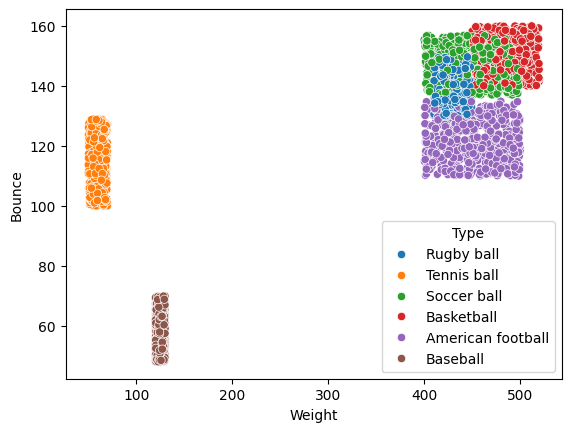

In [ ]:
#השלימו כאן קטע קוד
sns.scatterplot(x='Weight', y='Bounce', hue='Type', data=df)

<div dir="rtl">

**משימה**

איפה לדעתכם על סמך הגרף הנתון יהיה קשה למודל לסווג את הנתונים?



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='Green' size="5">
<b>
ענו כאן
פינה ימנית למעלה</font>
<br>

--------------------------------------------------------------------------------

<div dir="rtl">

# שלב 7 ואחרון חביב :ננסה לסווג נתון חדש

בואו ניצור נתון אחד חדש, כעת הנתונים הבאים ונראה איך המודל מסווג אותו, השתמשו בפונקציית predict:

In [ ]:
new_data = pd.DataFrame({
    'Weight': [408],
    'Bounce': [130]
})

#השלימו כאן קטע קוד
knn_model.predict(new_data)

array(['Rugby ball'], dtype=object)

<div dir="rtl">

# שלב התרגול וההבנה

אחרי שהרצנו יחד שלב אחר שלב מודל KNN, אימנו אותו ובדקנו אם עובד הגיע הזמן לשחק.
בצעו את המשימות הבאות:


<div dir="rtl">

# סעיף 1
הגדירו את המודל מחדש (אפשר עם משתנה חדש) עם K=5 ואמנו אותו עם המשתנים features_train, labels_train באמצעות המתודה fit
 לאחר מכן נסו לסווג שוב עם אותם הנתונים (new_data)


In [ ]:
#השלימו כאן קטע קוד
knn_model1 = KNeighborsClassifier(n_neighbors=5)

# Train the classifier on the training data
knn_model1.fit(features_train, labels_train)


KNeighborsClassifier()

In [ ]:
#השלימו כאן קטע קוד
knn_model1.predict(new_data)

array(['American football'], dtype=object)

<div dir="rtl">

**משימה**

האם יצא אותה התוצאה? אם לא, הסבירו מה קרה כאן.



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='Green' size="5">
<b>
ענו כאן
לא יצאה אותה תוצאה כיוון שבשני המודלים אשר ערך הK שונה זה לוקח בחשבון מספר שונה של עצמים שסביב העצם שאנחנו רוצים לסווג ולא תמיד באותו מספר של K תמיד תצא אותה תוצאה כי יכולה להיות שכאשר הל גדול יותר יהיה יותר סוגים של דברים שונים מאשר K מאוד קטן שיש מעט</font>
<br>


--------------------------------------------------------------------------------

<div dir="rtl">

# סעיף 2
נתונים נתוני הכדור בהרחבה בשם new_data_2.
שחזרו את השלבים החל מבחירת המשתנים בשלב 3.
עכשיו, הוסיפו למטריצת הפיצ'רים את הפיצ'רים Diameter ו-	Circumference.
הגדירו ואמנו מודל חדש בעל K=5.
בדקו מה יצא לכם עבור new_data_2.

In [ ]:
new_data_2 = pd.DataFrame({
    'Weight': [408],
    'Bounce': [130],
    'Circumference': [68],
    'Diameter': [27]
})

In [ ]:
#השלימו כאן קטע קוד
features2 = df[['Weight', 'Bounce', 'Circumference', 'Diameter']]

features_train2, features_test2, labels_train2, labels_test2 = train_test_split(features2 , labels , test_size=0.3, random_state=4)

new_model2 = KNeighborsClassifier(n_neighbors=5)
new_model2.fit(features_train2, labels_train2)

prid = new_model2.predict(new_data_2)
print(prid)

['Soccer ball']


<div dir="rtl">

**משימה**

האם יצא אותה התוצאה? אם לא, הסבירו מה קרה כאן.



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='Green' size="5">
<b>
ענו כאן
לא מפני ששינו את התכונות שהמודל בודק</font>
<br>

--------------------------------------------------------------------------------

<div dir="rtl">

# סעיף 3
בואו ננסה להוסיף את הפיצ'ר צורה....שלא השתמשנו בו עד כה.
הצורה של הכדור הנתון היא עגולה.
נסו להוסיף אותו לנתון ולמטריצה לשחזר את השלבים כמו בסעיף הקודם

In [ ]:
new_data_3 = pd.DataFrame({
    'Weight': [408],
    'Bounce': [130],
    'Circumference': [68],
    'Diameter': [27],
    'Shape':["Circle"]
})

In [ ]:
#השלימו כאן קטע קוד
features3 = df[['Weight', 'Bounce', 'Circumference', 'Diameter','Shape']]

features_train3, features_test3, labels_train3, labels_test3 = train_test_split(features3 , labels , test_size=0.3, random_state=4)

new_model3 = KNeighborsClassifier(n_neighbors=5)
new_model3.fit(features_train3, labels_train3)

prid = new_model3.predict(new_data_3)
print(prid)

ValueError: could not convert string to float: 'Ellipse'

<div dir="rtl">

**משימה**

אל תדאגו! הקוד היה אמור לקרוס, מדוע לדעתכם הוא קרס?

נסו לקרוא את השגיאה ולהבין מה הסיבה שהקוד קרס ולא הצלחנו לאמן את המודל



--------------------------------------------------------------------------------
<div dir="rtl">
<font color='Green' size="5">
<b>
ענו כאן
לא ניתן להעביר מילים למספרים שבעזרתם המודל יוככל לעשות את החישובים שהוא צריך כדי לעבוד</font>


--------------------------------------------------------------------------------

<div dir="rtl">

 אנו חייבים להפוך אותו למספר, זוכרים איך עושים זאת?
לא נורא נזכיר לכם. נשנה כל צורה שהיא עגולה ל-1 וכל צורה שהיא אליפסית ל0.
הריצו את השורה ההבאה:

In [ ]:
df['Shape'] = df['Shape'].map({'Circle':1, 'Ellipse':0})

<div dir="rtl">

עכשיו חיזרו לאותה הדוגמה מסעיף 2, הוסיפו לה את הפיצ'ר Shape עם פרמטר: צורה עגולה(אל תשכחו להכניס מספר ולא מחרוזת, מכיוון שהרגע הפכנו את כל המחרוזות למספרים), ובדקו האם הסיווג יישאר זהה כמו בסעיף 2.


In [ ]:
new_data_3 = pd.DataFrame({
    'Weight': [408],
    'Bounce': [130],
    'Circumference': [68],
    'Diameter': [27],
    'Shape':[1]
})

In [ ]:
#השלימו כאן קטע קוד
features3 = df[['Weight', 'Bounce', 'Circumference', 'Diameter', 'Shape']]

features_train3, features_test3, labels_train3, labels_test3 = train_test_split(features3, labels, test_size=0.3, random_state=4)

new_model3 = KNeighborsClassifier(n_neighbors=5)
new_model3.fit(features_train3, labels_train3)

prid1 = new_model3.predict(new_data_3)
print(prid1)

['Soccer ball']


<div dir="rtl">

**משימה**


מתי הסיווג היה המדוייק ביותר, נמקו מדוע?
האם לפיצ'ר שנוספתם הייתה השפעה?
האם הוא חשוב?




--------------------------------------------------------------------------------
<div dir="rtl">
<font color='Green' size="5">
<b>
ענו כאן
התוצאה לי יצאה זהה לסעיף הקודם אז מכך אני יכולה להסיק שלא היה לפיצר הנוסף שהוספתי השפעה כבדה</font>
<br>


--------------------------------------------------------------------------------

<div dir="rtl">

**משימה**

אם תשנו את הצורה לאליפסית האם התשובה של המודל תשתנה?



In [ ]:
# כתבו קוד כאן


--------------------------------------------------------------------------------
<div dir="rtl">
<font color='Green' size="5">
<b>
ענו כאן
לא</font>

--------------------------------------------------------------------------------

In [ ]:
#השלימו כאן קטע קוד
new_data_3 = pd.DataFrame({
    'Weight': [408],
    'Bounce': [130],
    'Circumference': [68],
    'Diameter': [27],
    'Shape':[0]
})


#השלימו כאן קטע קוד
features3 = df[['Weight', 'Bounce', 'Circumference', 'Diameter', 'Shape']]

features_train3, features_test3, labels_train3, labels_test3 = train_test_split(features3, labels, test_size=0.3, random_state=4)

new_model3 = KNeighborsClassifier(n_neighbors=5)
new_model3.fit(features_train3, labels_train3)

prid1 = new_model3.predict(new_data_3)
print(prid1)

['Soccer ball']


<div dir="rtl">

# בונוס
נסו לבחור בעצמכם **דוגמה אחרת** , עם נתונים אחרים  ולבחון אותה **ב2 צורות אימון שונות** , כאשר בכל פעם תבחרו פיצ'רים שונים וK שונה.

מה יצא לכם? האם אותו סיווג ? אם לא מדוע לדעתכם?

**תשובה:**

In [ ]:
#השלימו כאן קטע קוד


<div dir="rtl">

מוזמנים לנסות להחליף גם את סוג החיזוי , למשל לנסות לחזות צורה על סמך הפרמטרים השונים.
חישבו איזה שינוי נדרש על מנת לעשות זאת.

In [ ]:
#השלימו כאן קטע קוד
